# Building the Formula $$\eta_{it} = X_{i}\beta_{i} + Z_{it} + \epsilon_{it}$$ 

$\eta_{it}$ (The Prediction): This is the log-transformed population of region $i$ at time $t$. We use the "log" scale to stabilize the variance so a spike in Istanbul doesn't mathematically "drown out" a smaller trend in Bayburt.  

$X_{i}\beta_{i}$ (The Fixed Drivers): These are the things we know affect population. For us, $X$ is the design matrix containing your Births and Migration data. $\beta_i$ is the "weight" the model gives to those factors in that specific region.  

$Z_{it}$ (The Temporal Wiggles): This is the Gaussian Process (GP). Since births and migration don't explain everything (like the zoning amnesty of 2018), $Z_{it}$ captures the smooth, underlying "mood" of the population trend over time.  

$\epsilon_{it}$ (The Noise): This is the "extra-variability" or "unstructured noise". It’s the random statistical jitter that doesn't follow a pattern.  

## Step 1: 
$X_{i}\beta_{i}$ (The Fixed Drivers): These are the things we know affect population. For us, $X$ is the design matrix containing your Births and Migration data. $\beta_i$ is the "weight" the model gives to those factors in that specific region.  

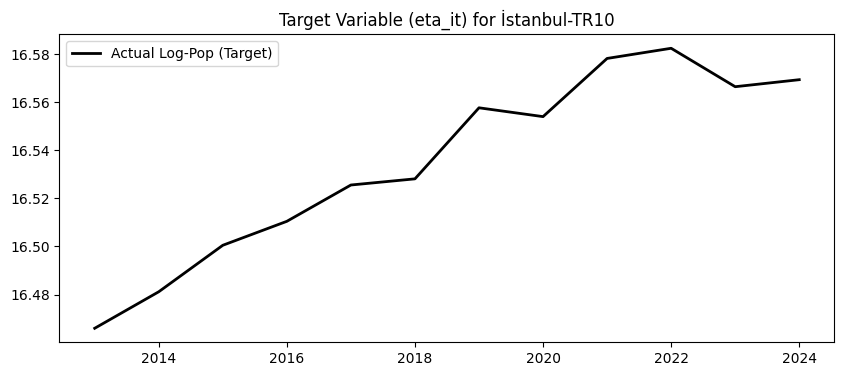

Design Matrix (X) first 3 rows:
[[  1.    229.39   66.321   0.   ]
 [  1.    242.397  14.336   1.   ]
 [  1.    242.888  50.543   2.   ]]


In [ ]:
from modules.data_loader import PopulationLoader
import matplotlib.pyplot as plt

loader = PopulationLoader(r'C:\Users\kerem\OneDrive\Masaüstü\VsCodeProjects\BLG610E_HomeWorks\project\datasets\master_dataset.csv')
df = loader.preprocess()

# Pick a district to examine (e.g., Istanbul)
region = "İstanbul-TR10"
y, X = loader.get_region_data(region)

plt.figure(figsize=(10, 4))
plt.plot(df[df['Region'] == region]['Year'], y, label="Actual Log-Pop (Target)", color='black', linewidth=2)
plt.title(f"Target Variable (eta_it) for {region}")
plt.legend()
plt.show()

print(f"Design Matrix (X) first 3 rows:\n{X[:3]}")

## Step 2: 
$Z_{it}$ (The Temporal Wiggles): This is the Gaussian Process (GP). Since births and migration don't explain everything (like the zoning amnesty of 2018), $Z_{it}$ captures the smooth, underlying "mood" of the population trend over time. 

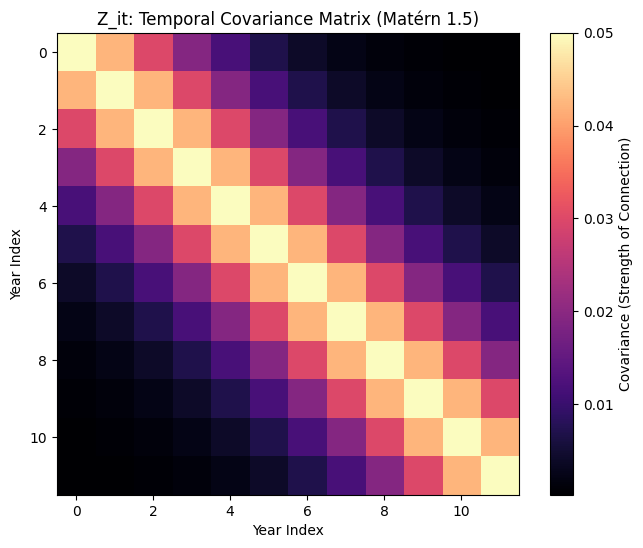

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from modules.gp_kernels import compute_covariance_matrix

# These are the region-specific parameters the model will eventually learn
sigma_sq_sample = 0.05  # The 'amplitude' of the wiggles
phi_sample = 2.5       # The 'range' of memory (in years)

# Time points from your master_dataset (2013-2024)
years = np.arange(2013, 2025)

# Generate the Covariance Matrix for a single district
K = compute_covariance_matrix(years, sigma_sq_sample, phi_sample)

# Visualization
plt.figure(figsize=(8, 6))
plt.imshow(K, cmap='magma')
plt.colorbar(label='Covariance (Strength of Connection)')
plt.title("Z_it: Temporal Covariance Matrix (Matérn 1.5)")
plt.xlabel("Year Index")
plt.ylabel("Year Index")
plt.show()

## Step 3:

Instead of letting each $\sigma_i^2$ (the amplitude of the "wiggles") be whatever it wants, the CAR prior says: $$\log(\sigma_i^2) \mid \log(\sigma_{j \neq i}^2) \sim \mathcal{N}\left(\frac{\rho_s \sum_{j} w_{ij} \log(\sigma_j^2)}{d_{ii}}, \frac{\tau^2}{d_{ii}}\right)$$
$\rho_s$ (Spatial Autocorrelation): A parameter (usually between 0 and 1) that controls how much a region cares about its neighbors.  

$d_{ii}$: The number of neighbors district $i$ has.

$W$ ($w_{ij}$): Your $26 \times 26$ Queen matrix.


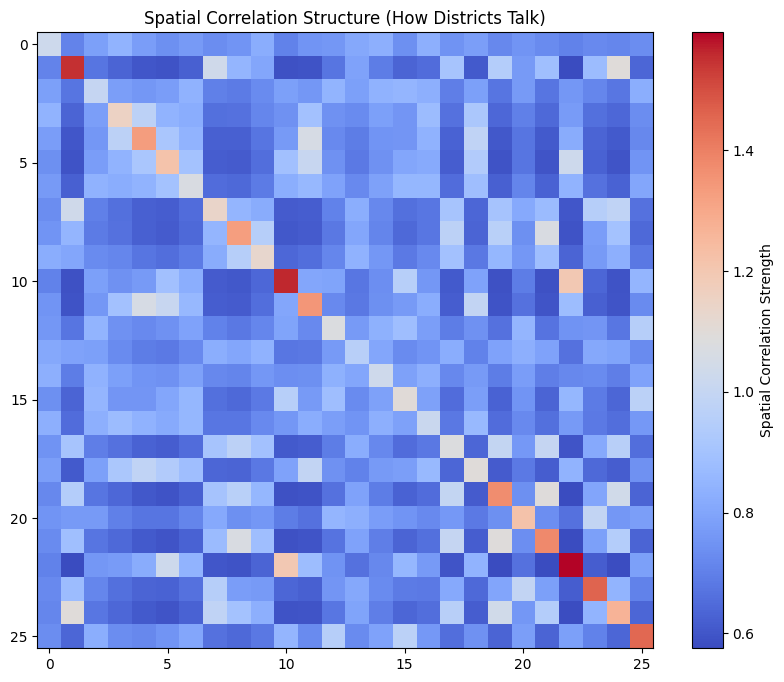

In [3]:
from modules.gp_kernels import compute_car_precision_matrix
from modules.project_constants import QUEEN_MATRIX, REGIONS

# Load the matrix you defined
W = np.array(QUEEN_MATRIX)

# Generate the Precision Matrix
# High rho_s means a district is STRONGLY forced to be like its neighbors
Q = compute_car_precision_matrix(W, rho_s=0.95)

plt.figure(figsize=(10, 8))
plt.imshow(np.linalg.inv(Q), cmap='coolwarm') # We plot the inverse to see the 'influence'
plt.colorbar(label='Spatial Correlation Strength')
plt.title("Spatial Correlation Structure (How Districts Talk)")
plt.show()

# Checking the model

Analyzing 3999 samples across 26 regions...


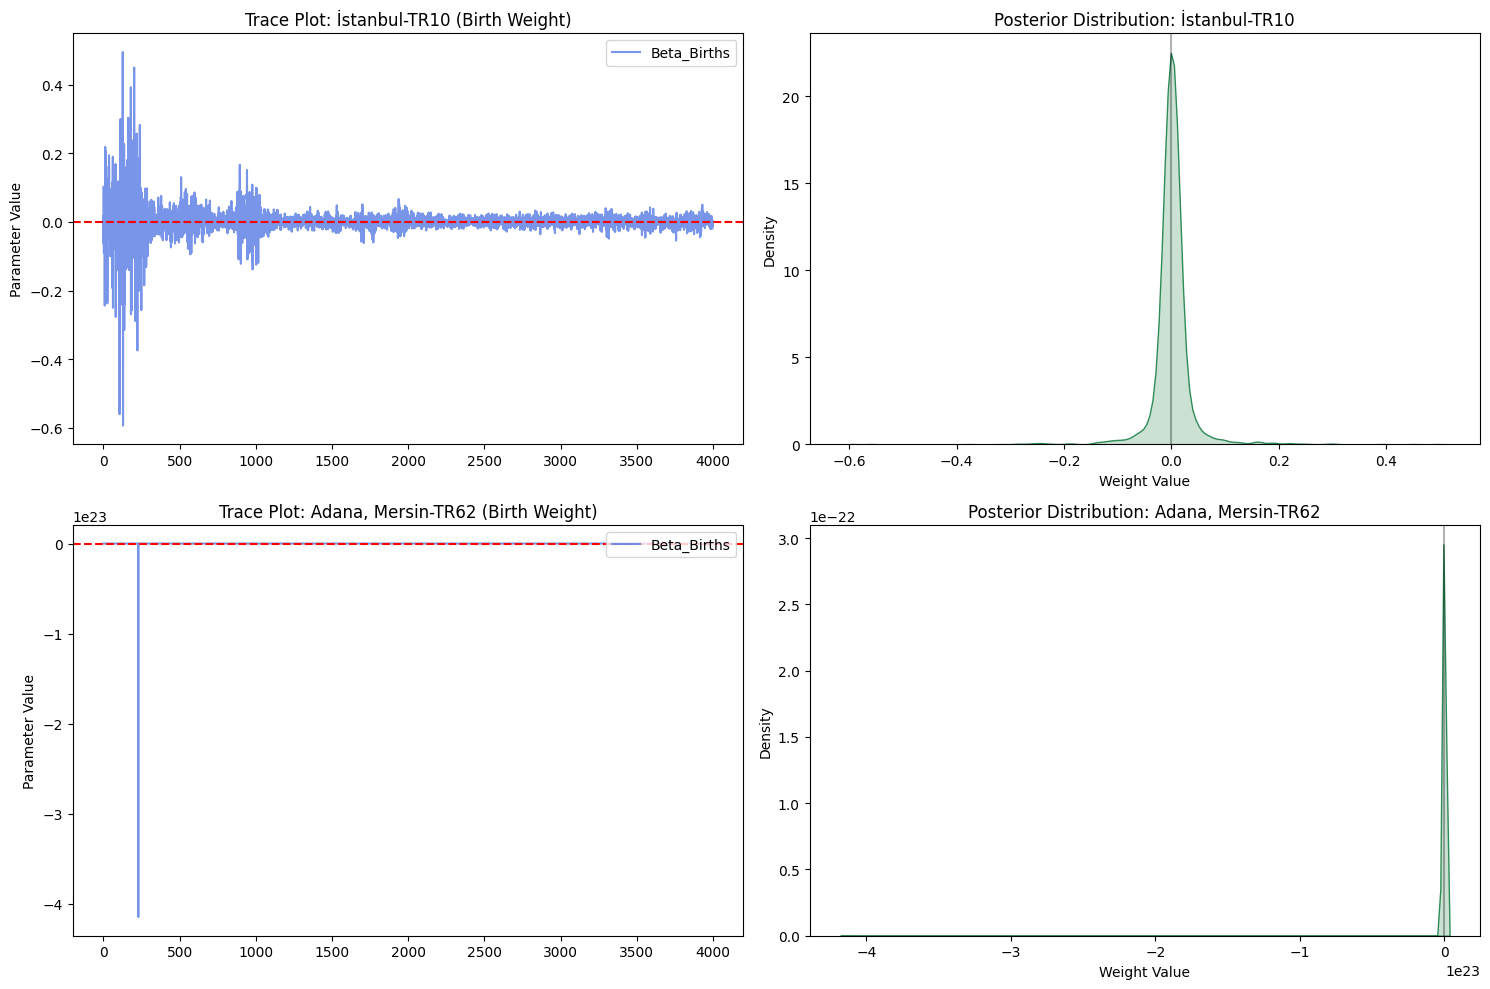


--- Model Inference Summary ---
Adana, Mersin-TR62 | Avg Birth Weight: -103765127557013782528.0000 | Avg Migration Weight: -6699323406020756480.0000
İstanbul-TR10   | Avg Birth Weight: 0.0007 | Avg Migration Weight: -0.0000


In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the results
with open('results/posterior_samples_50k.pkl', 'rb') as f:
    posterior_samples = pickle.load(f)

# 2. Setup the Dashboard
# We'll inspect Istanbul and a contrasting region to see the CAR prior effect
inspect_regions = [10, 0] # Adjust indices as needed for your specific regions
fig, axes = plt.subplots(len(inspect_regions), 2, figsize=(15, 5 * len(inspect_regions)))

print(f"Analyzing {len(posterior_samples)} samples across {len(REGIONS)} regions...")

for i, reg_idx in enumerate(inspect_regions):
    region_name = REGIONS[reg_idx]
    
    # Extract chains
    # Column 1: Births, Column 2: Migration
    birth_chain = [s['beta'][reg_idx][1] for s in posterior_samples]
    sigma_chain = [s['sigma'][reg_idx] for s in posterior_samples]
    
    # --- Column 0: Trace Plots (Convergence) ---
    axes[i, 0].plot(birth_chain, color='royalblue', alpha=0.7, label='Beta_Births')
    axes[i, 0].axhline(np.mean(birth_chain), color='red', linestyle='--')
    axes[i, 0].set_title(f"Trace Plot: {region_name} (Birth Weight)")
    axes[i, 0].set_ylabel("Parameter Value")
    axes[i, 0].legend(loc='upper right')
    
    # --- Column 1: Density Plots (Distribution) ---
    sns.kdeplot(birth_chain, ax=axes[i, 1], fill=True, color='seagreen', label='Post. Density')
    axes[i, 1].axvline(0, color='black', linestyle='-', alpha=0.3) # Zero line for significance check
    axes[i, 1].set_title(f"Posterior Distribution: {region_name}")
    axes[i, 1].set_xlabel("Weight Value")

plt.tight_layout()
plt.show()

# 3. Global Summary Statistics
all_betas = np.array([s['beta'] for s in posterior_samples]) # Shape: (4000, 26, 4)
mean_betas = np.mean(all_betas, axis=0)
std_betas = np.std(all_betas, axis=0)

print("\n--- Model Inference Summary ---")
for i, region in enumerate(REGIONS):
    if i in inspect_regions:
        b_mean = mean_betas[i, 1]
        m_mean = mean_betas[i, 2]
        print(f"{region:15} | Avg Birth Weight: {b_mean:6.4f} | Avg Migration Weight: {m_mean:6.4f}")

Generating Historical Trend Report (2013-2024)...


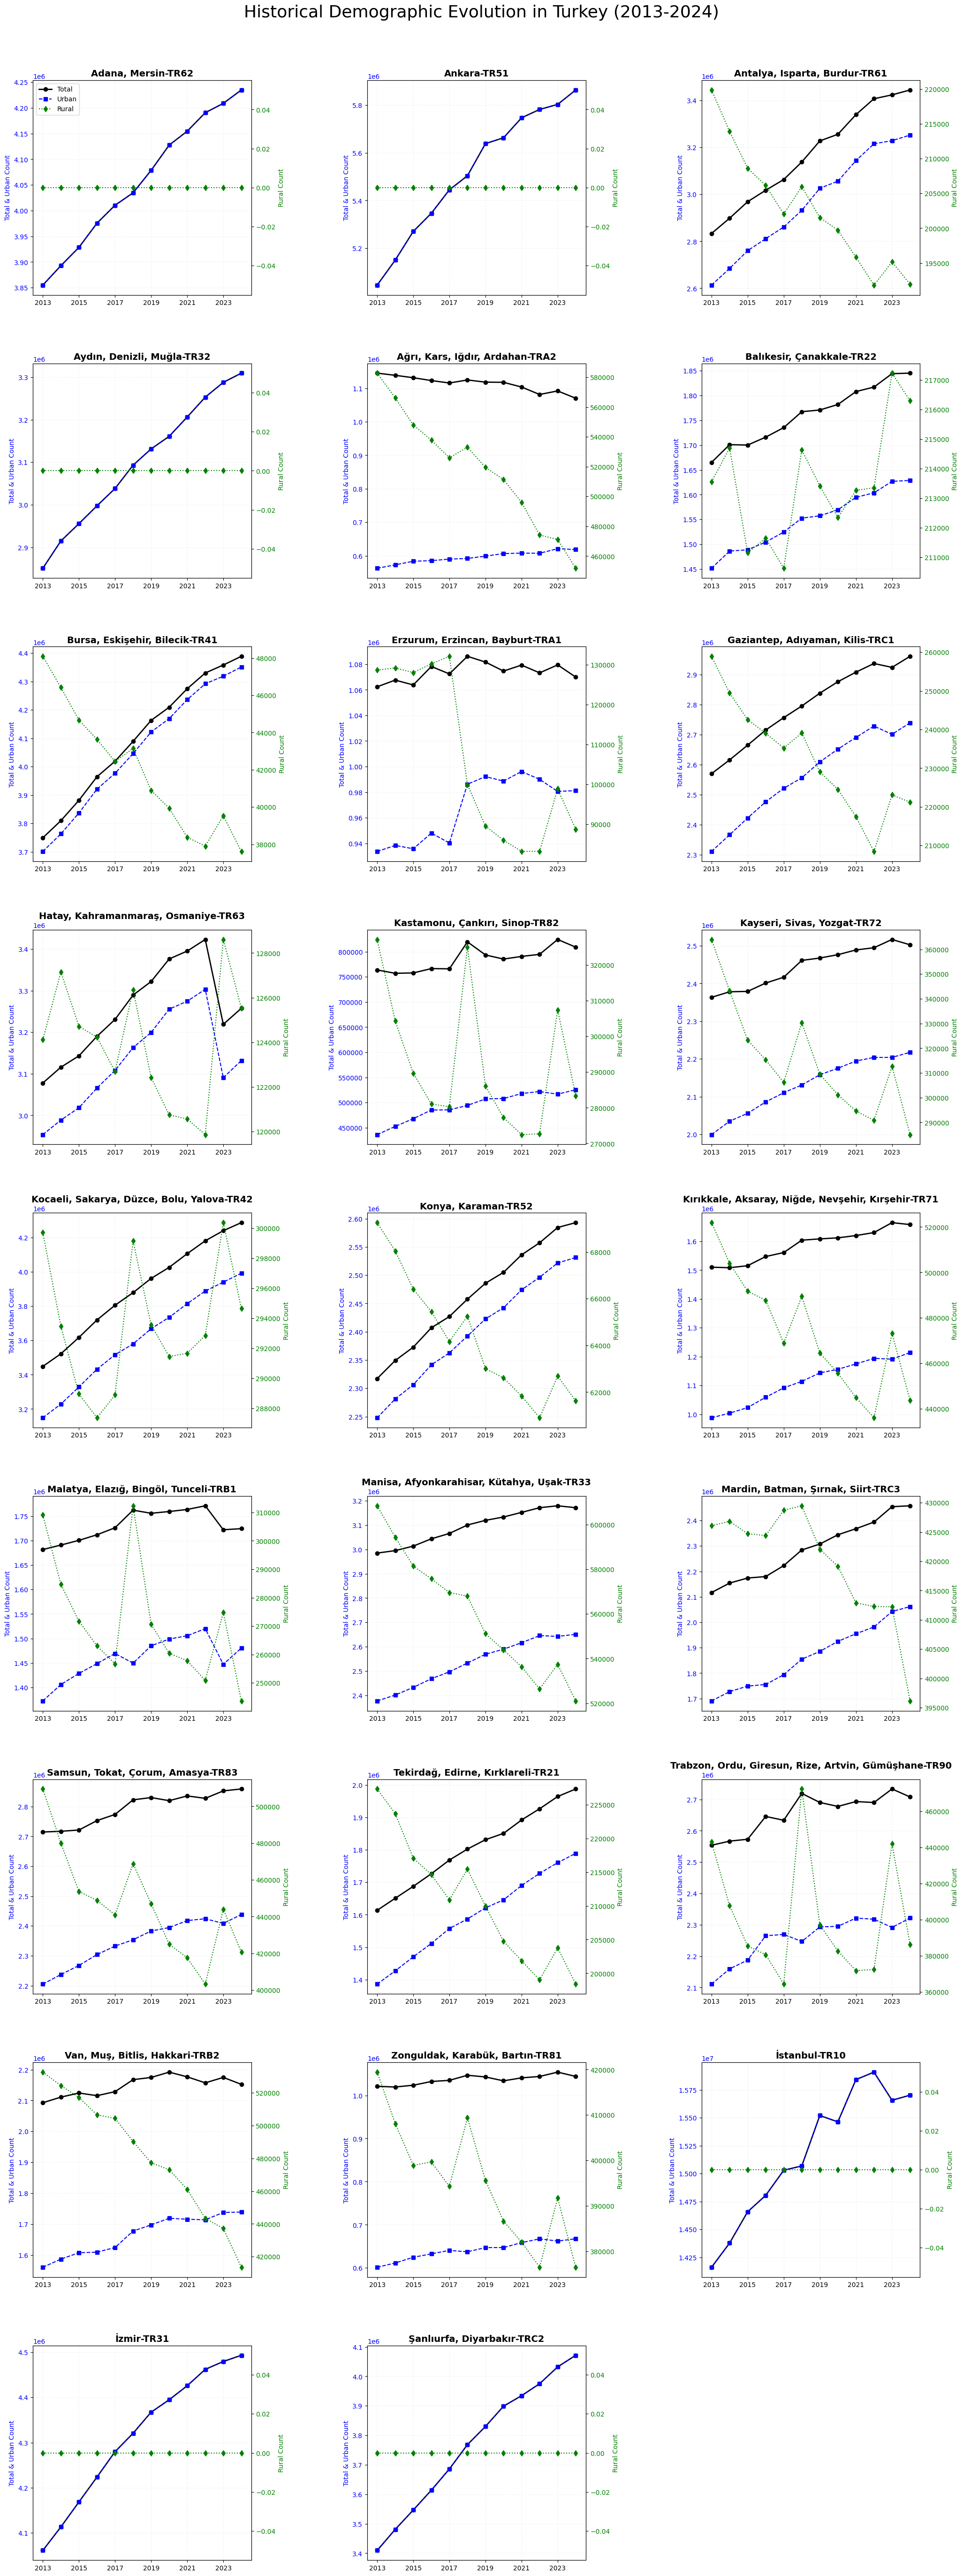

In [ ]:
import pandas as pd

# 1. Load the Historical Data
# Update the path to wherever your master_dataset.csv is located
df_hist = pd.read_csv(r"C:\Users\kerem\OneDrive\Masaüstü\VsCodeProjects\BLG610E_HomeWorks\project\datasets\master_dataset.csv")
regions = sorted(df_hist['Region'].unique())
years_hist = sorted(df_hist['Year'].unique())

# 2. Setup the National Dashboard (9x3 Grid for 26 Regions)
fig, axes = plt.subplots(nrows=9, ncols=3, figsize=(22, 55))
axes = axes.flatten()

print("Generating Historical Trend Report (2013-2024)...")

for i, region in enumerate(regions):
    ax1 = axes[i]
    
    # Filter and sort data for the current region
    reg_data = df_hist[df_hist['Region'] == region].sort_values('Year')
    h_years = reg_data['Year'].values
    h_total = reg_data['Total_Population'].values
    h_urban = reg_data['Urban'].values
    h_rural = reg_data['Rural'].values
    
    # --- Axis 1: Total & Urban (Left Y-Axis) ---
    ax1.plot(h_years, h_total, color='black', marker='o', linewidth=2, label='Total')
    ax1.plot(h_years, h_urban, color='blue', linestyle='--', marker='s', linewidth=1.5, label='Urban')
    
    ax1.set_ylabel('Total & Urban Count', color='blue', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, alpha=0.15, linestyle='--')
    
    # --- Axis 2: Rural (Right Y-Axis) ---
    # Using twinx() allows us to see the rural trend regardless of its small scale
    ax2 = ax1.twinx()
    ax2.plot(h_years, h_rural, color='green', linestyle=':', marker='d', linewidth=1.5, label='Rural')
    
    ax2.set_ylabel('Rural Count', color='green', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='green')
    
    # Formatting the subplot
    ax1.set_title(f"{region}", fontsize=14, fontweight='bold')
    ax1.set_xticks(h_years[::2]) # Show every 2nd year to prevent label overlapping
    
    # Add a unified legend to the first plot
    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True)

# Remove the empty 27th slot
if len(axes) > len(regions):
    for j in range(len(regions), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout(pad=6.0)
plt.suptitle("Historical Demographic Evolution in Turkey (2013-2024)", fontsize=26, y=1.01)
plt.show()

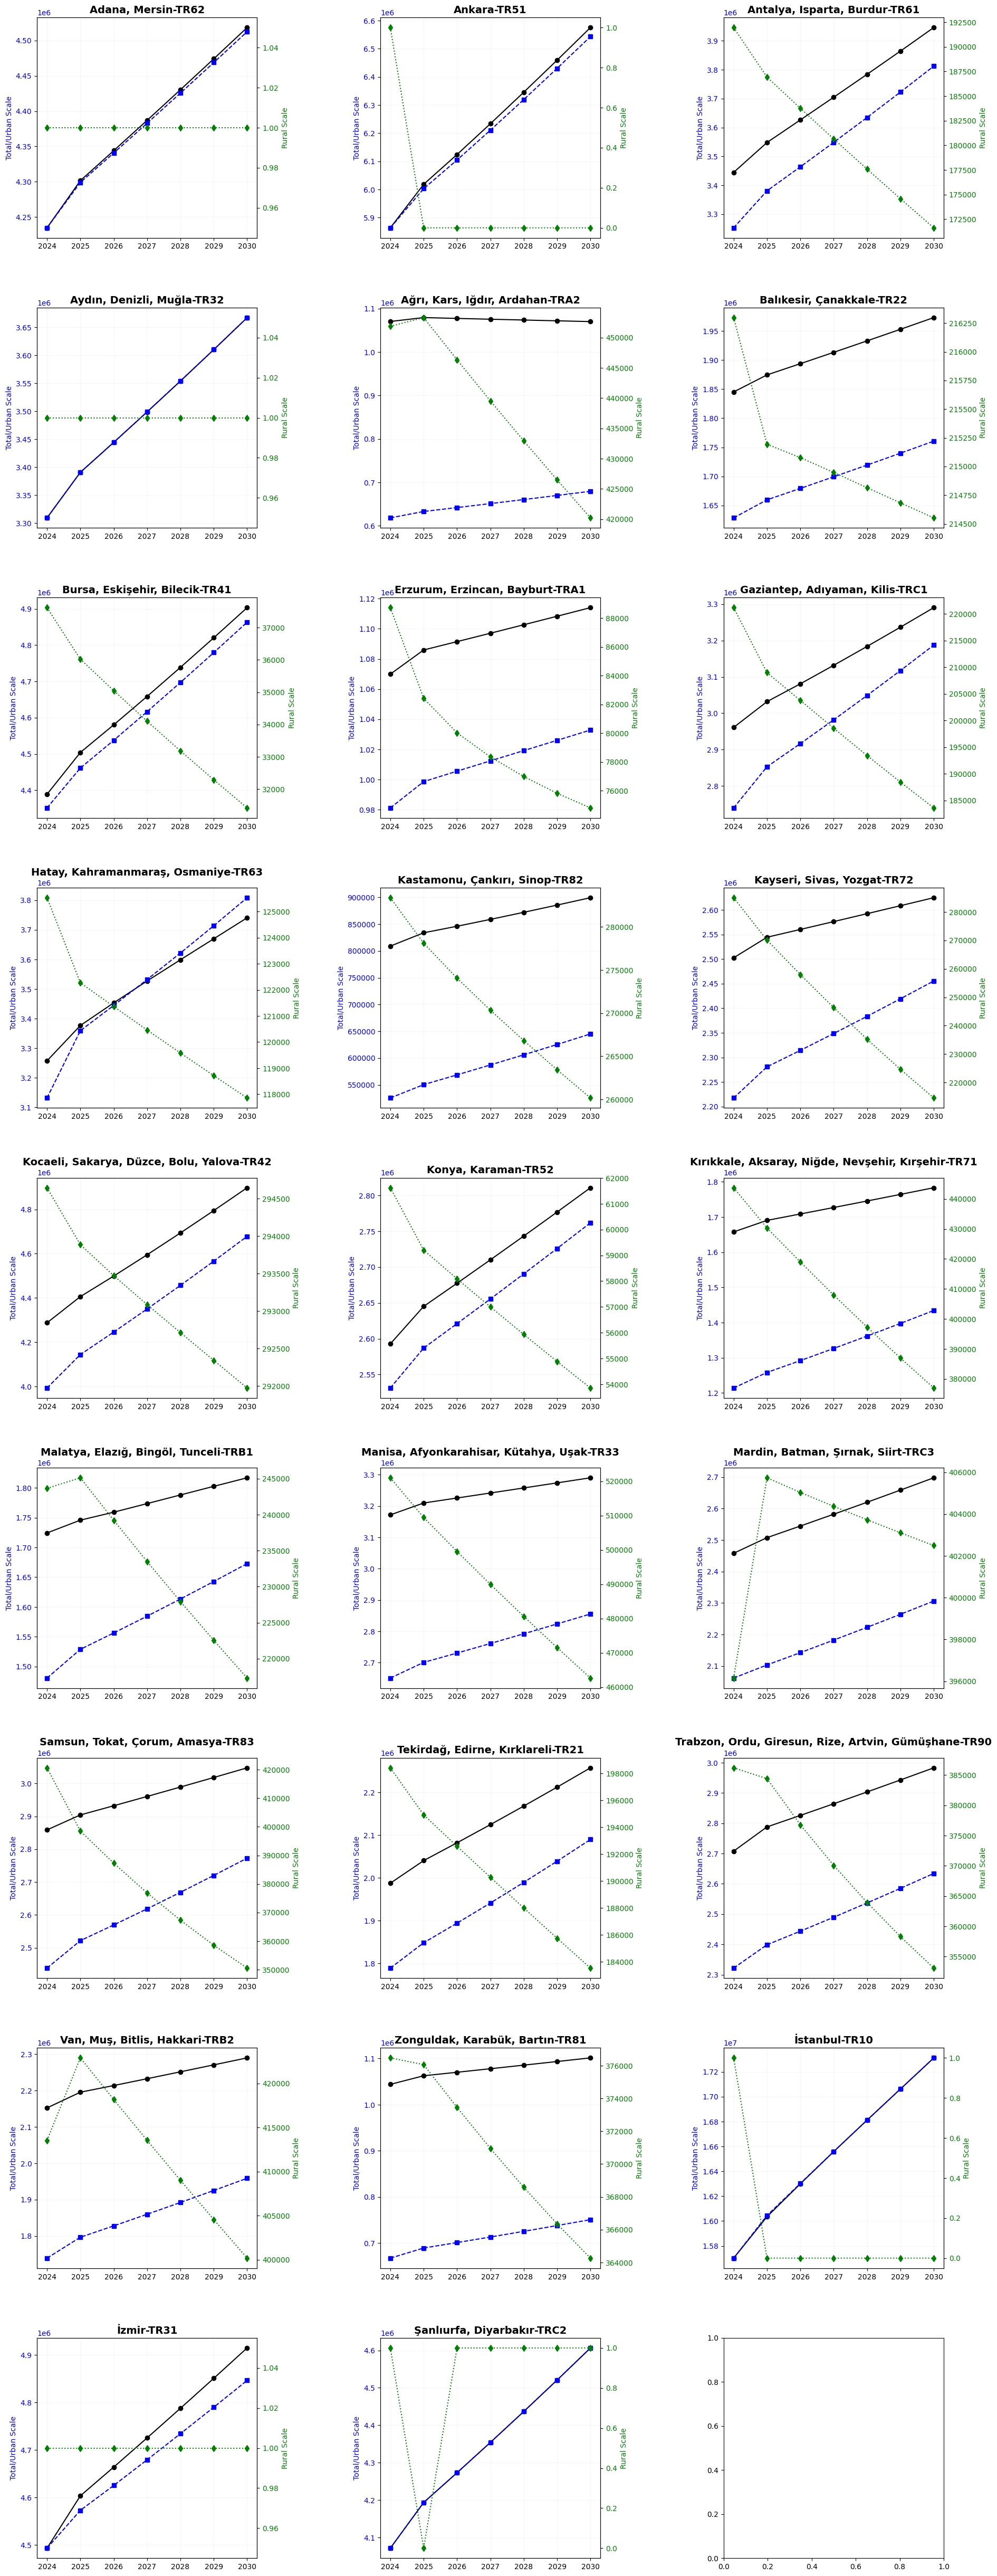

In [ ]:
# 1. Load the generated data
df = pd.read_csv('results/comprehensive_2030_report.csv')
years = [2024, 2025, 2026, 2027, 2028, 2029, 2030]
regions = df['Region'].unique()

fig, axes = plt.subplots(nrows=9, ncols=3, figsize=(20, 50))
axes = axes.flatten()

for i, region in enumerate(regions):
    ax1 = axes[i]
    row = df[df['Region'] == region]
    
    total_vals = [row[f'Total_{y}'].values[0] for y in years]
    urban_vals = [row[f'Urban_{y}'].values[0] for y in years]
    rural_vals = [row[f'Rural_{y}'].values[0] for y in years]
    
    # Axis 1: Total and Urban (Left)
    ax1.plot(years, total_vals, color='black', marker='o', label='Total')
    ax1.plot(years, urban_vals, color='blue', linestyle='--', marker='s', label='Urban')
    ax1.set_ylabel('Total/Urban Scale', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # Axis 2: Rural (Right) - Use twinx() to create a secondary axis
    ax2 = ax1.twinx()
    ax2.plot(years, rural_vals, color='green', linestyle=':', marker='d', label='Rural')
    ax2.set_ylabel('Rural Scale', color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    
    ax1.set_title(f"{region}", fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.1)

plt.tight_layout(pad=5.0)
plt.show()

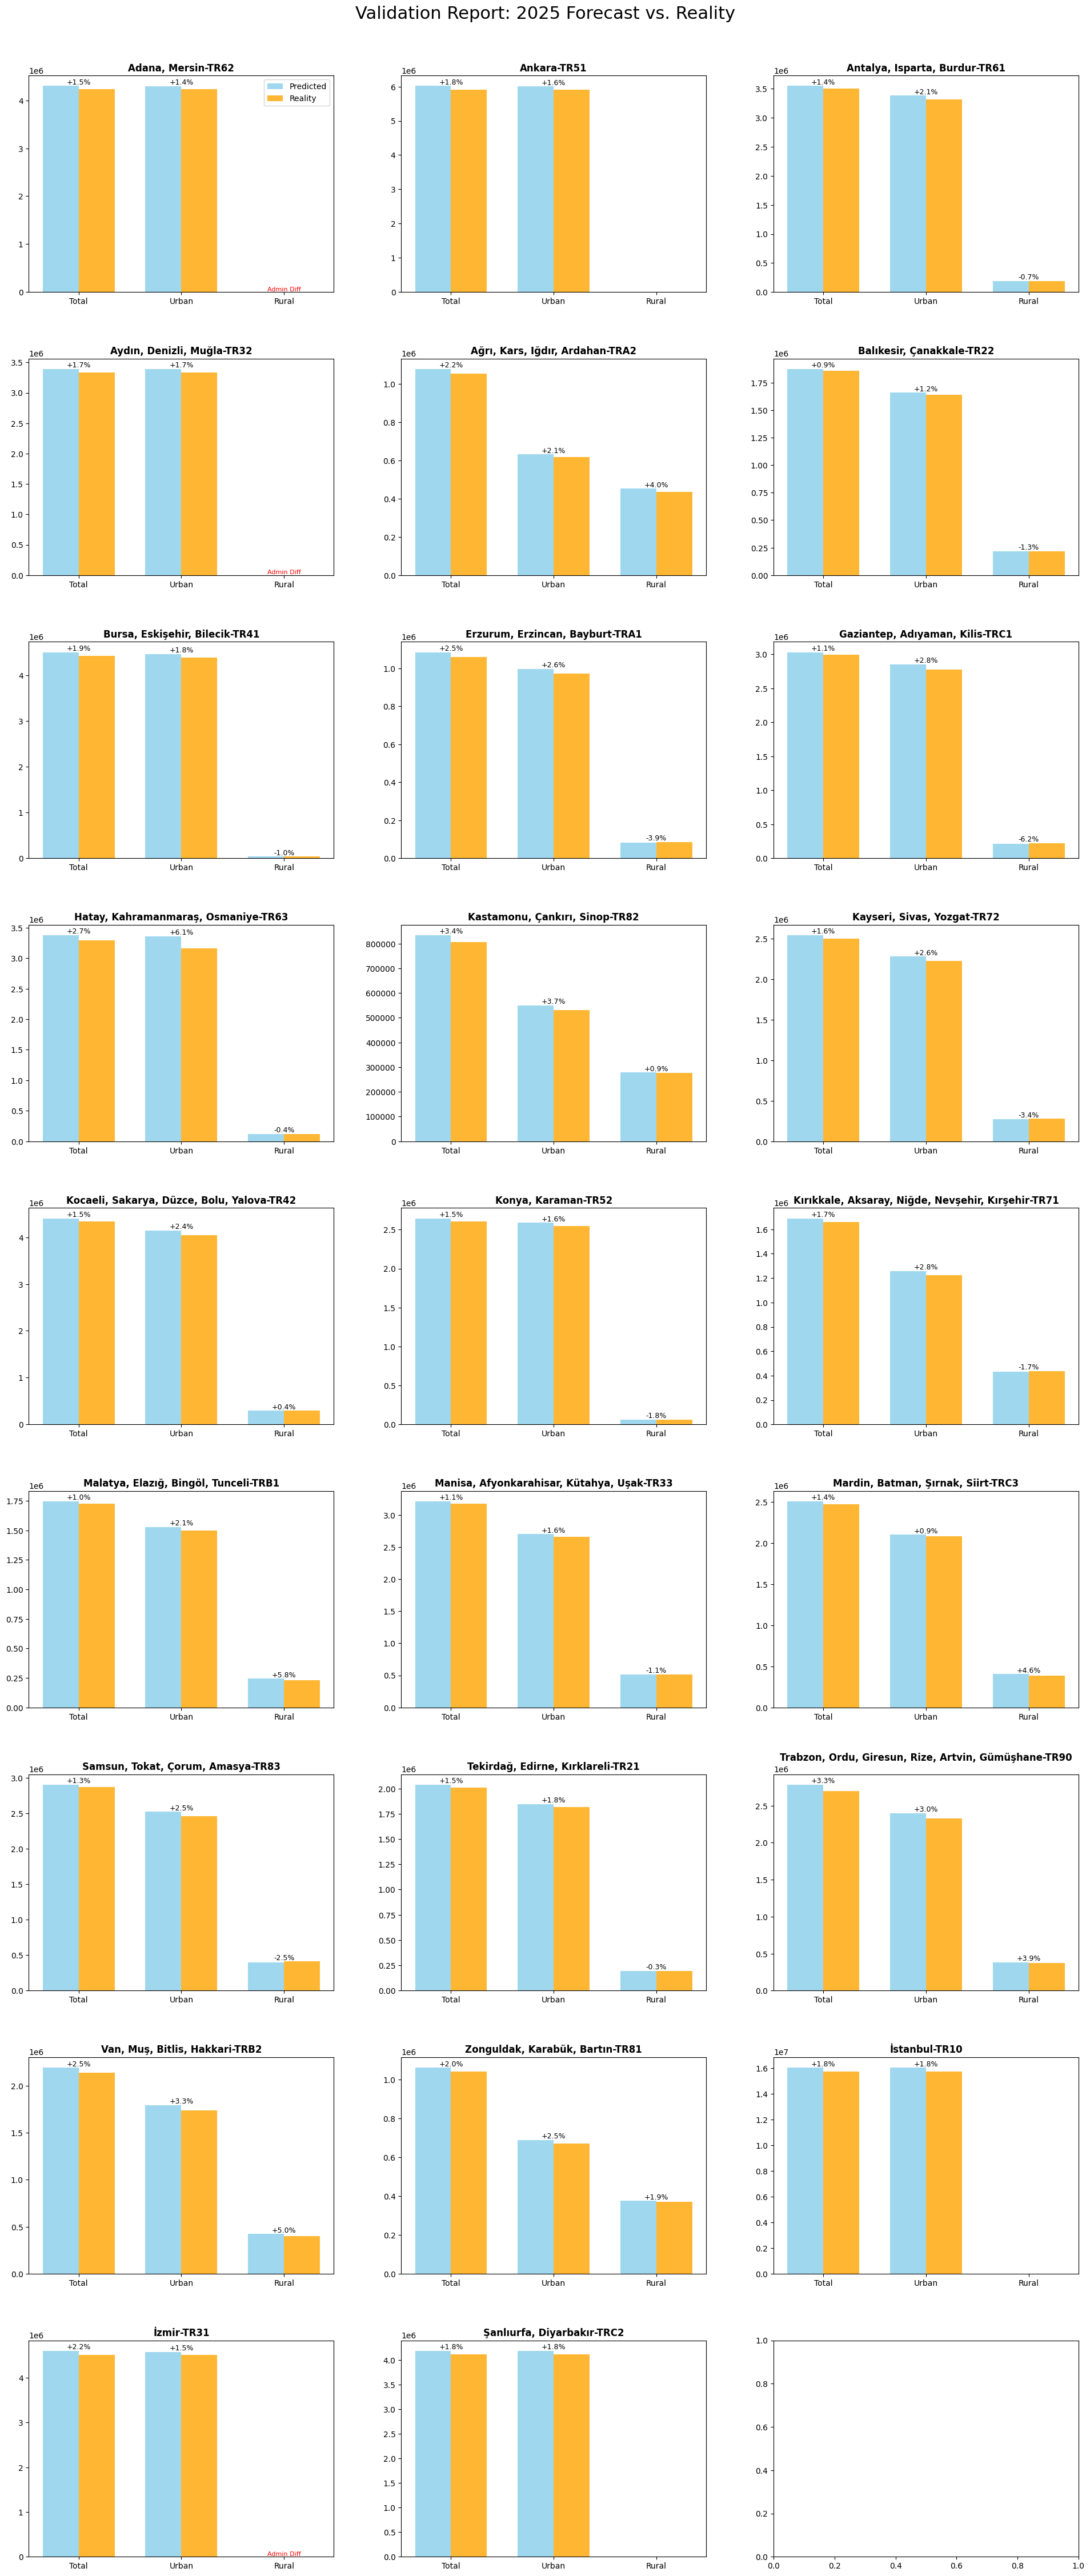


--- Accuracy Metrics (2025) ---
MAPE for Total: 1.82%
MAPE for Urban: 2.29%
MAPE for Rural: 2.52%


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the Predictions and the Ground Truth
df_pred = pd.read_csv('results/comprehensive_2030_report.csv')
df_real = pd.read_csv('results/rural_vs_urban.csv')

# We only care about the ground truth for 2025
df_real_2025 = df_real[df_real['Year'] == 2025].copy()

# 3. Alignment
# We rename columns for clarity during the merge
df_real_2025 = df_real_2025.rename(columns={
    'Total_Population': 'Total_2025_Real',
    'Urban': 'Urban_2025_Real',
    'Rural': 'Rural_2025_Real'
})

# Merge our 2030 report with the 2025 real data
comparison_df = pd.merge(df_pred, df_real_2025[['Region', 'Total_2025_Real', 'Urban_2025_Real', 'Rural_2025_Real']], on='Region')

# 4. Visualization (Comparative Bar Chart for 2025)
fig, axes = plt.subplots(nrows=9, ncols=3, figsize=(20, 45))
axes = axes.flatten()

for i, region in enumerate(comparison_df['Region'].unique()):
    ax = axes[i]
    row = comparison_df[comparison_df['Region'] == region]
    
    categories = ['Total', 'Urban', 'Rural']
    predicted = [row['Total_2025'].values[0], row['Urban_2025'].values[0], row['Rural_2025'].values[0]]
    real = [row['Total_2025_Real'].values[0], row['Urban_2025_Real'].values[0], row['Rural_2025_Real'].values[0]]
    
    x = np.arange(len(categories))
    width = 0.35
    
    ax.bar(x - width/2, predicted, width, label='Predicted', color='skyblue', alpha=0.8)
    ax.bar(x + width/2, real, width, label='Reality', color='orange', alpha=0.8)
    
    # Calculate and show % error on the plot
    for j in range(len(categories)):
        if real[j] > 0:
            error = ((predicted[j] - real[j]) / real[j]) * 100
            ax.text(x[j], max(predicted[j], real[j]), f'{error:+.1f}%', ha='center', va='bottom', fontsize=9)
        elif predicted[j] > 0 and real[j] == 0:
            ax.text(x[j], predicted[j], 'Admin Diff', ha='center', va='bottom', fontsize=8, color='red')

    ax.set_title(f"{region}", fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    if i == 0: ax.legend()

plt.tight_layout(pad=4.0)
plt.suptitle("Validation Report: 2025 Forecast vs. Reality", fontsize=22, y=1.01)
plt.show()

# 5. Global Accuracy Summary
print("\n--- Accuracy Metrics (2025) ---")
for cat in categories:
    pred_col = f'{cat}_2025'
    real_col = f'{cat}_2025_Real'
    # Mean Absolute Percentage Error (ignoring zeros in reality)
    mask = comparison_df[real_col] > 0
    mape = np.mean(np.abs((comparison_df.loc[mask, pred_col] - comparison_df.loc[mask, real_col]) / comparison_df.loc[mask, real_col])) * 100
    print(f"MAPE for {cat}: {mape:.2f}%")